In [1]:

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.prompts import ChatPromptTemplate
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END, MessagesState

import os
import operator
from typing import Annotated, Literal
from pydantic import BaseModel
from tavily import TavilyClient
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage

from langgraph.prebuilt import ToolNode
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
# Section 2 — Document Loading
loader = PyPDFLoader("../documents/evs_oil_price_shock.pdf")
raw_docs = loader.load()

print(f"Loaded {len(raw_docs)} pages")


Loaded 15 pages


In [3]:
# Section 3 — Text Chunking
splitter = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150)
chunks = splitter.split_documents(raw_docs)

print(f"Split into {len(chunks)} chunks")

Split into 51 chunks


In [4]:
# Section 4 — Embedding Model
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

In [5]:
# in-memory only; re-running this cell re-embeds from scratch
vectorstore = Chroma(
    collection_name="rag_conditional",
    embedding_function=embeddings,
)

vectorstore.add_documents(documents=chunks)

retriever = vectorstore.as_retriever(search_kwargs={"k": 4})
print("Vector store ready")

Vector store ready


In [6]:
llm = ChatOpenAI(model="gpt-5-mini")        # route_question and generate

agent_llm = ChatOpenAI(model="gpt-5-mini")  # agent node; tools bound later

In [7]:
# define the state of graph.
class AgenticRAGState(MessagesState):

    query: str
    retrieved_docs: Annotated[list[Document], operator.add]
    context: Annotated[str, operator.add]
    generation: str
    needs_retrieval: bool

    # new param retry and fallback:
    retrieval_count: int
    max_retrieval_steps: int

    # retrieval eval and rewrite:
    relevant_docs: list[Document]
    is_relevant: bool
    rewritten_query: str  
    rewrite_count: int   


In [8]:
class RouteDecision(BaseModel):
    
    needs_retrieval: bool

class RelevanceEvaluation(BaseModel):
    
    is_relevant: bool

In [9]:
# define the two tools 
# 1. knowledeg base tool.
# 2. web-serach tool.

@tool(response_format="content_and_artifact")
def vector_store_search(query : str, k: int = 3):

    """
    Search the vector store for relevant document passages.
    Adjust k (default 3) to retrieve more or fewer passages.
    """

    retriever = vectorstore.as_retriever(search_kwargs={"k": k})
    docs = retriever.invoke(query)

    context = "\n\n ## Vector Store Result" + "\n\n".join(d.page_content for d in docs)

    return context, docs


@tool(response_format="content_and_artifact")
def web_search(query : str, max_results: int = 3):
    """ 
    search the web for current or real-time information.
    Adjust max_results (default 3) to control how many results are returned.
    """

    client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])
    response = client.search(query, max_results=max_results)
    
    docs = [
        Document(
            page_content=r["content"],
            metadata={"source": r["url"], "title": r.get("title", "")},
        )
        for r in response["results"]
    ]

    context = "\n\n ## Web Search Results" + "\n\n".join(d.page_content for d in docs)

    return context, docs


In [10]:
tools = [vector_store_search, web_search]
agent_llm_with_tools = agent_llm.bind_tools(tools)
tool_node = ToolNode(tools)

In [11]:
# route_question node — classifies whether the query needs retrieval
def route_question(state: AgenticRAGState) -> dict:

    prompt_template = ChatPromptTemplate.from_messages([
        ("system", "Classify whether the following question requires retrieving information from a specialized document or the web, or can be answered from your own general knowledge."),
        ("human", "{query}"),
    ])

    chain = prompt_template | llm.with_structured_output(RouteDecision)
    decision = chain.invoke({"query": state["query"]})

    return {"needs_retrieval": decision.needs_retrieval}

In [ ]:
AGENT_SYSTEM_PROMPT = (
    "You are a retrieval agent with access to two tools:\n\n"
    "1. vector_store_search — use this for questions that can be answered from the internal document: "
    "a technical report titled 'Will EVs Dampen the Oil Price Shock?' covering EV adoption trajectories, "
    "oil demand displacement scenarios, fleet turnover dynamics, battery cost trends, OPEC+ supply behavior, "
    "and energy price volatility projections through 2050. "
    "Use this tool whenever the query references the report, its findings, its projections, or any topic "
    "that would plausibly appear in a domain-specific EV/oil-market research document. "
    "You may increase k beyond the default if broader coverage of the document is needed.\n\n"
    "2. web_search — use this for current or real-time information not covered by the document, such as "
    "recent market data, news, or statistics from 2024 onward. "
    "Always rephrase the query into a concise, keyword-optimized web search string before calling this tool.\n\n"
    "You may call one tool, both tools, or no tool depending on what the query requires. "
    "When both document knowledge and current data are relevant, call both tools."
)



def agent(state: AgenticRAGState) -> dict:


    # use rewritten_query if available to start a fresh retrieval cycle
    rewritten = state.get("rewritten_query")
    if rewritten:
        messages = [
            SystemMessage(content = AGENT_SYSTEM_PROMPT),
            HumanMessage(content=rewritten)
        ]

    else:
    
        messages = state["messages"]
        if not messages:
            messages = [
                SystemMessage(content=AGENT_SYSTEM_PROMPT),
                HumanMessage(content=state["query"]),
            ]

    response = agent_llm_with_tools.invoke(messages)
    return {"messages": [response]}

In [13]:
#  collect_tool_output node — drains ToolMessages into state fields
def collect_tool_output(state: AgenticRAGState) -> dict:

    all_docs = []

    for msg in reversed(state['messages']):
        if isinstance(msg, HumanMessage):
            break
        if isinstance(msg, ToolMessage):
            all_docs.append(msg.artifact)

    all_docs.reverse()

    return {'retrieved_docs': all_docs}


In [14]:
def evaluate_docs(state: AgenticRAGState) -> dict:
    
    docs = state.get('retrieved_docs') or []

    if not docs:
        return {"is_relevant": False, "relevant_docs": [], "context": ""} 
    
    active_query = state.get('rewritten_query') or state.get('query')


    prompt_template = ChatPromptTemplate.from_messages([
        (
            "system",
            "You are a relevance evaluator. Given a user query and a single document passage, "
            "determine whether the passage contains useful information to answer the query. "
            "Return is_relevant=True only if the passage directly addresses the query with specific facts or analysis. "
            "Return is_relevant=False if it is off-topic, too vague, or does not help answer the query."
        ),
        ("human", "Query: {query}\n\nDocument passage:\n{doc}"),
    ])

    chain = prompt_template | llm.with_structured_output(RelevanceEvaluation)

    relevant_docs = []
    for doc in docs:
        result = chain.invoke({"query": active_query, "doc": doc.page_content})
        if result.is_relevant:
            relevant_docs.append(doc)


    is_relevant = len(relevant_docs) > 0

    context = "\n\n".join(d.page_content for d in relevant_docs)

    return {
        "is_relevant": is_relevant, 
        "relevant_docs": relevant_docs,
        "context": context
    }
    

In [15]:
def rewrite_query(state: AgenticRAGState) -> dict:

    count = state.get('rewrite_count', 0)

    prompt_template = ChatPromptTemplate.from_messages([
        (
            "system",
            "You are a query rewriting assistant. A retrieval system searched for information to answer the user's "
            "query but none of the retrieved documents were relevant. Your task is to rewrite the query to be more "
            "specific, use different terminology, or focus on a narrower aspect that is more likely to match "
            "content in the knowledge source. Return only the rewritten query string."
        ),
        ("human", "Original query: {query}\n\nRewritten query:"),
    ]) 

    chain = prompt_template | llm
    response = chain.invoke({"query": state["query"]})
    new_query = response.content.strip()
    return {"rewritten_query": new_query, "rewrite_count": count + 1}

In [16]:
# generate node — produces the final answer with or without retrieved context
def generate(state: AgenticRAGState) -> dict:

    # no-answer fallback when all rewrite attempts are exhausted with no relevant docs
    if state.get("rewrite_count", 0) >= 3 and not state.get("is_relevant"):
        return {
            "generation": (
                "I was unable to find relevant information to answer your query after multiple retrieval attempts. "
                "The knowledge source does not appear to contain content that addresses this question."
            )
        }



    query = state["query"]
    context = state.get("context") or ""

    if context:
        prompt_template = ChatPromptTemplate.from_messages([
            ("system", "Answer the question using only the context below.\n\nContext:\n{context}"),
            ("human", "{query}"),
        ])
        response = (prompt_template | llm).invoke({"context": context, "query": query})

    else:
        prompt_template = ChatPromptTemplate.from_messages([
            ("system", "Answer the following question from your general knowledge."),
            ("human", "{query}"),
        ])
        response = (prompt_template | llm).invoke({"query": query})

    return {"generation": response.content}

In [17]:
def check_retrieval_limit(state: AgenticRAGState) -> dict:
    count = state.get("retrieval_count", 0)
    return {"retrieval_count": count + 1}

In [19]:
def route_after_classification(state: AgenticRAGState) -> Literal['agent', 'generate']:

    if state['needs_retrieval']:
        return "agent"
    return "generate"


def route_after_agent(state: AgenticRAGState) -> Literal["tools", "collect_tool_output"]:
    if state['messages'][-1].tool_calls:
        return "tools"
    return "collect_tool_output"


def route_after_limit_check(state: AgenticRAGState) -> Literal['agent', 'collect_tool_output']:

    if state['retrieval_count'] >= state['max_retrieval_steps']:
        return "collect_tool_output"
    return "agent"
    

def route_after_evaluation(state: AgenticRAGState) -> Literal["generate", "rewrite_query"]:

    if state["is_relevant"]:
        return "generate"
    return "rewrite_query"


def route_after_rewrite(state: AgenticRAGState) -> Literal['generate', 'agent']:
    
    if state.get("rewrite_count", 0) >= 3:
        return "generate"
    return "agent"

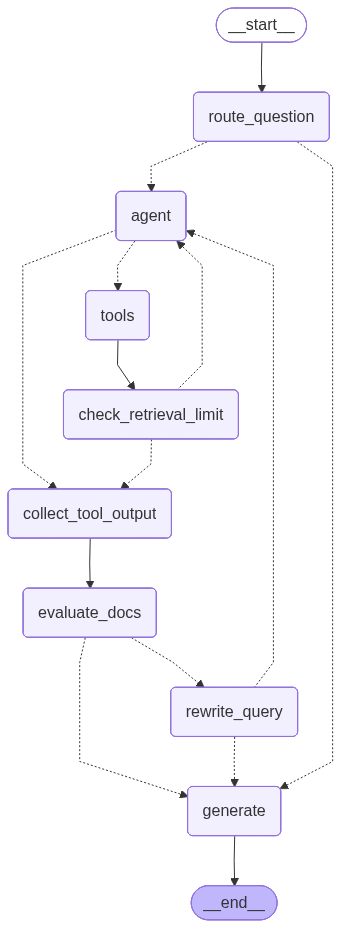

In [20]:

graph_builder = StateGraph(AgenticRAGState)

# add node
graph_builder.add_node('route_question', route_question)
graph_builder.add_node("agent", agent)
graph_builder.add_node("tools", tool_node)
graph_builder.add_node("check_retrieval_limit", check_retrieval_limit)
graph_builder.add_node("collect_tool_output", collect_tool_output)
graph_builder.add_node('generate', generate)
graph_builder.add_node('evaluate_docs', evaluate_docs)
graph_builder.add_node('rewrite_query', rewrite_query)


# add edge 

graph_builder.add_edge(START, "route_question")
graph_builder.add_conditional_edges('route_question', route_after_classification)
graph_builder.add_conditional_edges('agent', route_after_agent)
graph_builder.add_edge('tools', "check_retrieval_limit")
graph_builder.add_conditional_edges('check_retrieval_limit', route_after_limit_check)
graph_builder.add_edge('collect_tool_output', 'evaluate_docs')
graph_builder.add_conditional_edges('evaluate_docs', route_after_evaluation)
graph_builder.add_conditional_edges('rewrite_query', route_after_rewrite)
graph_builder.add_edge('generate', END)


graph = graph_builder.compile()
graph

In [ ]:
query_1 = (
    "According to the report, by how many million barrels per day could a 300-million EV fleet "
    "displace oil demand by 2030, and what does this mean relative to total global demand?"
)

result_1 = graph.invoke({
    "query": query_1,
    "messages": [],
    "retrieved_docs": [],
    "relevant_docs": [],
    "context": "",
    "retrieval_count": 0,
    "max_retrieval_steps": 3,
    "rewrite_count": 0,
    "rewritten_query": "",
})

print("=== Case 1: Specific domain query ===")
print("Is relevant:", result_1.get("is_relevant"))
print("Relevant docs count:", len(result_1.get("relevant_docs") or []))
print("Rewrite count:", result_1.get("rewrite_count"))
print("\nGeneration:\n", result_1.get("generation"))

In [ ]:
query_2 = (
    "how long people take to get rid of their vehicles completely as per the report?"
)

result_2 = graph.invoke({
    "query": query_2,
    "messages": [],
    "retrieved_docs": [],
    "relevant_docs": [],
    "context": "",
    "retrieval_count": 0,
    "max_retrieval_steps": 3,
    "rewrite_count": 0,
    "rewritten_query": "",
})

print("=== Case 2: Informal query — rewrite then succeeds ===")
print("Is relevant:", result_2.get("is_relevant"))
print("Relevant docs count:", len(result_2.get("relevant_docs") or []))
print("Rewrite count:", result_2.get("rewrite_count"))
print("Rewritten query:", result_2.get("rewritten_query"))
print("\nGeneration:\n", result_2.get("generation"))

In [ ]:
query_3 = "What does the report/document say about nuclear power?"

result_3 = graph.invoke({
    "query": query_3,
    "messages": [],
    "retrieved_docs": [],
    "relevant_docs": [],
    "context": "",
    "retrieval_count": 0,
    "max_retrieval_steps": 3,
    "rewrite_count": 0,
    "rewritten_query": "",
})

print("=== Case 3: Off-topic query — max rewrites exhausted ===")
print("Is relevant:", result_3.get("is_relevant"))
print("Relevant docs count:", len(result_3.get("relevant_docs") or []))
print("Rewrite count:", result_3.get("rewrite_count"))
print("Rewritten query:", result_3.get("rewritten_query"))

In [ ]:
query_4 = "What is the chemical symbol for lithium and what group of the periodic table does it belong to?"

result_4 = graph.invoke({
    "query": query_4,
    "messages": [],
    "retrieved_docs": [],
    "relevant_docs": [],
    "context": "",
    "retrieval_count": 0,
    "max_retrieval_steps": 3,
    "rewrite_count": 0,
    "rewritten_query": "",
})

print("=== Case 4: General knowledge — no retrieval ===")
print("Needs retrieval:", result_4.get("needs_retrieval"))
print("Is relevant:", result_4.get("is_relevant"))
print("Rewrite count:", result_4.get("rewrite_count"))
print("\nGeneration:\n", result_4.get("generation"))